# 📉 Mục 3 — Advanced Data Visualization
## German Credit Risk Scoring Application

> **Nội dung:** ROC Curve, Precision-Recall Curve, Confusion Matrix theo Threshold, Expected Cost Curve — đầy đủ so sánh Logistic Regression vs SVM.

---

## ⚙️ Bước 1 — Cấu hình & Tìm đường dẫn Data

In [1]:
import os

def find_data_path():
    search_bases = [
        os.getcwd(),
        os.path.join(os.getcwd(), '..'),
        os.path.join(os.getcwd(), '..', '..'),
        os.path.join(os.getcwd(), 'Data'),
        os.path.join(os.getcwd(), '..', 'Data'),
    ]
    for base in search_bases:
        for sub in ['Data', '']:
            candidate = os.path.normpath(os.path.join(base, sub, 'german.data'))
            if os.path.exists(candidate):
                return candidate
    return None

DATA_PATH = find_data_path()
if DATA_PATH is None:
    DATA_PATH = r'C:\DAP_PRroject_Final\Data\german.data'
    print(f'[WARNING] Dùng đường dẫn thủ công: {DATA_PATH}')
else:
    print(f'[OK] Data: {DATA_PATH}')
print(f'[OK] Tồn tại: {os.path.exists(DATA_PATH)}')

[OK] Data: c:\DAP_PRroject_Final\Data\german.data
[OK] Tồn tại: True


## 📦 Bước 2 — Import thư viện & Hằng số

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc,
    confusion_matrix, roc_auc_score,
    average_precision_score, classification_report,
    f1_score, recall_score, precision_score
)

plt.style.use('dark_background')

C = {
    'bg':     '#0f1117', 'card':   '#1e2235', 'border': '#2e3350',
    'lr':     '#4f8ef7', 'svm':    '#7c5cbf', 'base':   '#888780',
    'good':   '#22c55e', 'bad':    '#ef4444', 'warn':   '#f59e0b',
    'text':   '#e8eaf6', 'muted':  '#8892b0', 'purple': '#7c5cbf',
}

COST_FN = 5   # False Negative: phân loại Bad → Good (nguy hiểm hơn)
COST_FP = 1   # False Positive: phân loại Good → Bad

print('✅ Thư viện sẵn sàng.')
print(f'   Cost matrix: FN × {COST_FN}  |  FP × {COST_FP}')

✅ Thư viện sẵn sàng.
   Cost matrix: FN × 5  |  FP × 1


## 📥 Bước 3 — Load dữ liệu & Tiền xử lý

In [3]:
COLUMNS = [
    'checking', 'duration', 'credit_history', 'purpose', 'amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age',
    'other_plans', 'housing', 'existing_credits', 'job',
    'dependents', 'telephone', 'foreign_worker', 'label'
]

df = pd.read_csv(DATA_PATH, sep=' ', header=None, names=COLUMNS)
y  = (df['label'] == 2).astype(int)   # 1 = Bad Credit, 0 = Good Credit
X  = df.drop('label', axis=1)

# One-hot encoding cho categorical features
cat_cols = [
    'checking', 'credit_history', 'purpose', 'savings', 'employment',
    'personal_status', 'other_debtors', 'property', 'other_plans',
    'housing', 'job', 'telephone', 'foreign_worker'
]
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# StandardScaler cho numeric features
num_cols = ['duration', 'amount', 'installment_rate',
            'residence_since', 'age', 'existing_credits', 'dependents']
scaler = StandardScaler()
X_enc[num_cols] = scaler.fit_transform(X_enc[num_cols])

# Train/Test split 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} mẫu  |  Test: {X_test.shape[0]} mẫu')
print(f'Features: {X_train.shape[1]}')
print(f'Test  → Good: {sum(y_test==0)}  |  Bad: {sum(y_test==1)}')

Train : 800 mẫu  |  Test: 200 mẫu
Features: 48
Test  → Good: 140  |  Bad: 60


## 🏋️ Bước 4 — Train Logistic Regression & SVM

In [4]:
print('Training Logistic Regression...')
lr = LogisticRegression(
    C=1.0, class_weight='balanced',
    max_iter=1000, random_state=42, solver='lbfgs'
)
lr.fit(X_train, y_train)

print('Training SVM (RBF kernel)...')
svm = SVC(
    kernel='rbf', C=1.0, gamma='scale', probability=True,
    class_weight='balanced', random_state=42
)
svm.fit(X_train, y_train)

prob_lr  = lr.predict_proba(X_test)[:, 1]
prob_svm = svm.predict_proba(X_test)[:, 1]

auc_lr  = roc_auc_score(y_test, prob_lr)
auc_svm = roc_auc_score(y_test, prob_svm)

print()
print(f'✅ Logistic Regression  ROC-AUC: {auc_lr:.4f}')
print(f'✅ SVM (RBF)            ROC-AUC: {auc_svm:.4f}')

Training Logistic Regression...
Training SVM (RBF kernel)...

✅ Logistic Regression  ROC-AUC: 0.8074
✅ SVM (RBF)            ROC-AUC: 0.7940


## 📈 Bước 5 — ROC Curve

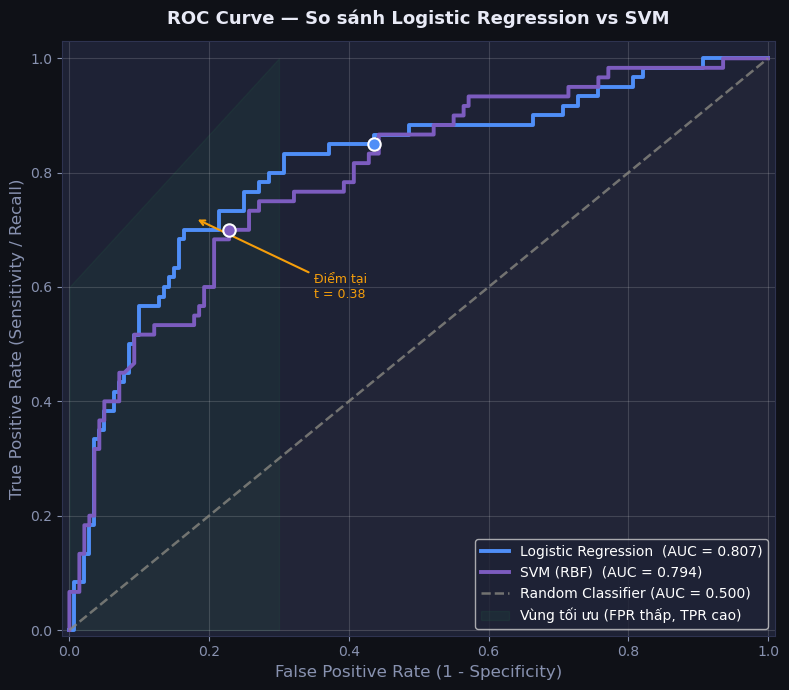

💾 Lưu: roc_curve.png

  LR  ROC-AUC = 0.8074
  SVM ROC-AUC = 0.7940
  LR tốt hơn SVM: True


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['card'])

# Vẽ ROC cho từng model
models = [
    (prob_lr,  'Logistic Regression', C['lr']),
    (prob_svm, 'SVM (RBF)',           C['svm']),
]

for prob, name, color in models:
    fpr, tpr, thresholds_roc = roc_curve(y_test, prob)
    roc_auc_v = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.8,
            label=f'{name}  (AUC = {roc_auc_v:.3f})')
    # Đánh dấu điểm tại threshold 0.38
    idx = np.argmin(np.abs(thresholds_roc - 0.38))
    ax.scatter(fpr[idx], tpr[idx], color=color, s=80,
               zorder=5, edgecolors='white', linewidths=1.5)

# Baseline
ax.plot([0, 1], [0, 1], '--', color=C['base'],
        linewidth=1.8, label='Random Classifier (AUC = 0.500)', alpha=0.8)
ax.fill_between([0, 1], [0, 1], alpha=0.04, color=C['base'])

# Vùng tối ưu
ax.fill_between([0, 0.3], [0.6, 1], alpha=0.06, color=C['good'],
                label='Vùng tối ưu (FPR thấp, TPR cao)')

ax.set_xlabel('False Positive Rate (1 - Specificity)',
              color=C['muted'], fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)',
              color=C['muted'], fontsize=12)
ax.set_title('ROC Curve — So sánh Logistic Regression vs SVM',
             color=C['text'], fontsize=13, pad=12, fontweight='bold')
ax.tick_params(colors=C['muted'])
ax.legend(loc='lower right', fontsize=10,
          facecolor=C['card'], labelcolor='white')
ax.grid(alpha=0.15)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.03)
for spine in ax.spines.values():
    spine.set_edgecolor(C['border'])

# Annotation
ax.annotate('Điểm tại\nt = 0.38',
            xy=(0.18, 0.72), xytext=(0.35, 0.58),
            arrowprops=dict(arrowstyle='->', color=C['warn'], lw=1.5),
            color=C['warn'], fontsize=9)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: roc_curve.png')
print(f'\n  LR  ROC-AUC = {auc_lr:.4f}')
print(f'  SVM ROC-AUC = {auc_svm:.4f}')
print(f'  LR tốt hơn SVM: {auc_lr > auc_svm}')

## 📈 Bước 6 — Precision-Recall Curve

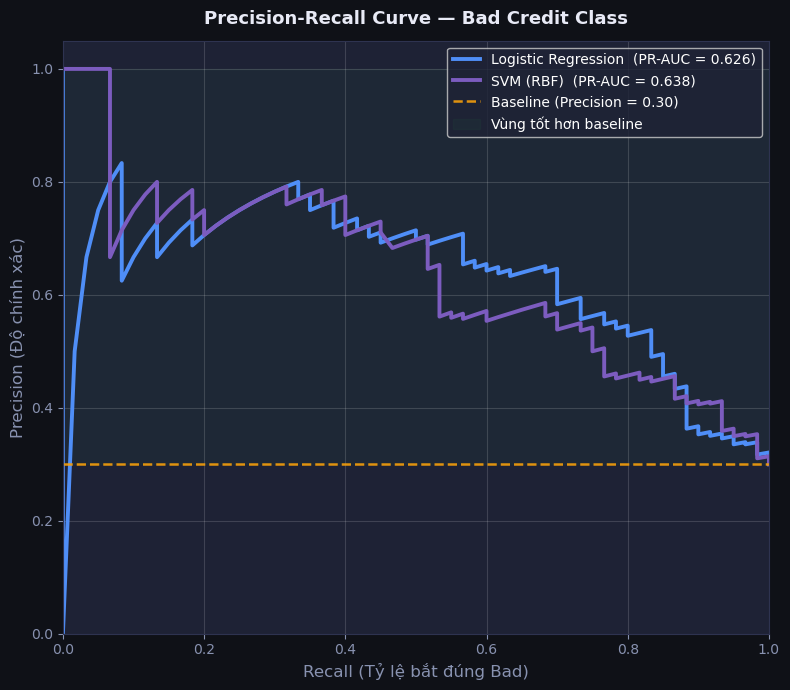

💾 Lưu: pr_curve.png

  LR  PR-AUC = 0.6259
  SVM PR-AUC = 0.6376
  Baseline   = 0.30


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['card'])

baseline_p = y_test.mean()  # Tỷ lệ Bad trong test set

for prob, name, color in models:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr_auc_v = auc(rec, prec)
    ax.plot(rec, prec, color=color, linewidth=2.8,
            label=f'{name}  (PR-AUC = {pr_auc_v:.3f})')

ax.axhline(y=baseline_p, color=C['warn'], linestyle='--', linewidth=1.8,
           label=f'Baseline (Precision = {baseline_p:.2f})', alpha=0.9)
ax.fill_between([0, 1], [baseline_p, baseline_p], [1, 1],
                alpha=0.04, color=C['good'], label='Vùng tốt hơn baseline')

ax.set_xlabel('Recall (Tỷ lệ bắt đúng Bad)', color=C['muted'], fontsize=12)
ax.set_ylabel('Precision (Độ chính xác)', color=C['muted'], fontsize=12)
ax.set_title('Precision-Recall Curve — Bad Credit Class',
             color=C['text'], fontsize=13, pad=12, fontweight='bold')
ax.tick_params(colors=C['muted'])
ax.legend(loc='upper right', fontsize=10,
          facecolor=C['card'], labelcolor='white')
ax.grid(alpha=0.15)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
for spine in ax.spines.values():
    spine.set_edgecolor(C['border'])

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: pr_curve.png')

pr_lr  = auc(*precision_recall_curve(y_test, prob_lr)[:2][::-1])
pr_svm = auc(*precision_recall_curve(y_test, prob_svm)[:2][::-1])
print(f'\n  LR  PR-AUC = {pr_lr:.4f}')
print(f'  SVM PR-AUC = {pr_svm:.4f}')
print(f'  Baseline   = {baseline_p:.2f}')

## 🎚️ Bước 7 — Confusion Matrix theo Threshold (Interactive)

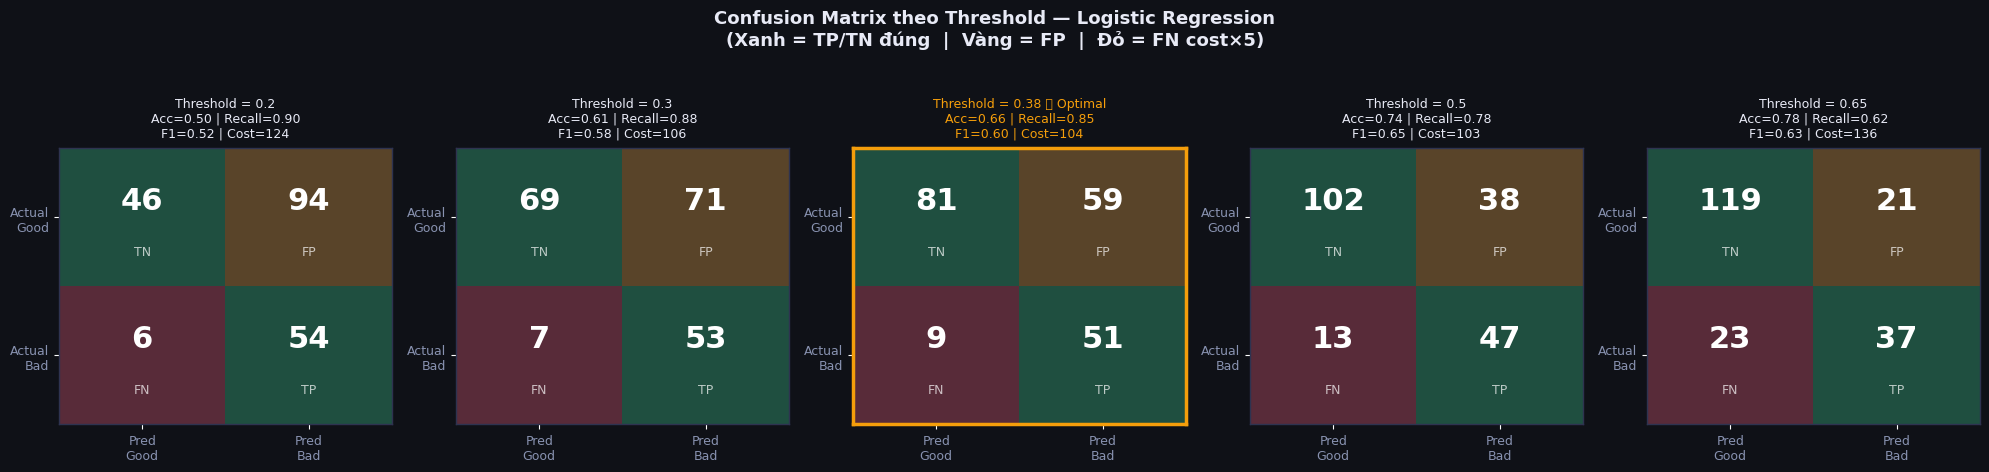

💾 Lưu: confusion_by_threshold.png

📌 Threshold 0.38 được đánh dấu ⭐ vì tối ưu theo cost matrix 5:1


In [7]:
thresholds_cm = [0.20, 0.30, 0.38, 0.50, 0.65]

fig, axes = plt.subplots(1, len(thresholds_cm), figsize=(20, 4.5))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    'Confusion Matrix theo Threshold — Logistic Regression\n'
    '(Xanh = TP/TN đúng  |  Vàng = FP  |  Đỏ = FN cost×5)',
    color=C['text'], fontsize=13, fontweight='bold', y=1.04
)

for ax, t in zip(axes, thresholds_cm):
    preds = (prob_lr >= t).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm_t.ravel()

    cell_colors = [[C['good'], C['warn']], [C['bad'], C['good']]]
    cell_vals   = [[tn, fp], [fn, tp]]
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j], alpha=0.28, linewidth=0
            ))
            ax.text(j + 0.5, 1.62 - i, str(cell_vals[i][j]),
                    ha='center', va='center',
                    fontsize=22, fontweight='bold', color='white')
            ax.text(j + 0.5, 1.25 - i, cell_labels[i][j],
                    ha='center', va='center',
                    fontsize=9, color='white', alpha=0.7)

    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Pred\nGood', 'Pred\nBad'], color=C['muted'], fontsize=9)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Actual\nBad', 'Actual\nGood'], color=C['muted'], fontsize=9)

    acc        = (tn + tp) / len(y_test)
    recall_bad = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_bad   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_bad     = 2 * prec_bad * recall_bad / (prec_bad + recall_bad) if (prec_bad + recall_bad) > 0 else 0
    exp_cost   = fn * COST_FN + fp * COST_FP

    is_optimal = abs(t - 0.38) < 0.01
    border_color = C['warn'] if is_optimal else C['border']
    title_color  = C['warn'] if is_optimal else C['text']
    border_lw    = 2.5 if is_optimal else 1

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(border_lw)

    title_str = f'Threshold = {t}'
    if is_optimal: title_str += ' ⭐ Optimal'
    ax.set_title(
        f'{title_str}\nAcc={acc:.2f} | Recall={recall_bad:.2f}\n'
        f'F1={f1_bad:.2f} | Cost={exp_cost}',
        color=title_color, fontsize=9, pad=8
    )
    ax.set_facecolor(C['card'])

plt.tight_layout()
plt.savefig('confusion_by_threshold.png', dpi=150, bbox_inches='tight',
            facecolor=C['bg'])
plt.show()
print('💾 Lưu: confusion_by_threshold.png')
print()
print('📌 Threshold 0.38 được đánh dấu ⭐ vì tối ưu theo cost matrix 5:1')

## 📊 Bước 8 — Bảng Metrics theo Threshold

In [8]:
thresholds_range = np.arange(0.20, 0.71, 0.05)

rows = []
for t in thresholds_range:
    pred = (prob_lr >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm_t.ravel()
    acc  = (tn + tp) / len(y_test)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    cost = fn * COST_FN + fp * COST_FP
    rows.append({
        'Threshold': round(t, 2),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy': round(acc, 3),
        'Recall(Bad)': round(rec, 3),
        'Precision(Bad)': round(prec, 3),
        'F1(Bad)': round(f1, 3),
        'Expected Cost': int(cost),
    })

df_thresh = pd.DataFrame(rows)
df_thresh_styled = df_thresh.style.highlight_min(
    subset=['Expected Cost'], color='#1e5c36'
).highlight_max(
    subset=['Recall(Bad)'], color='#1e3a5c'
)
print('Bảng metrics Logistic Regression theo threshold:\n')
df_thresh

Bảng metrics Logistic Regression theo threshold:



,Threshold,TP,FP,FN,TN,Accuracy,Recall(Bad),Precision(Bad),F1(Bad),Expected Cost
0,0.20,54,94,6,46,0.500,0.900,0.365,0.519,124
1,0.25,53,81,7,59,0.560,0.883,0.396,0.546,116
2,0.30,53,71,7,69,0.610,0.883,0.427,0.576,106
3,0.35,52,65,8,75,0.635,0.867,0.444,0.588,105
4,0.40,51,55,9,85,0.680,0.850,0.481,0.614,100
5,0.45,50,45,10,95,0.725,0.833,0.526,0.645,95
6,0.50,47,38,13,102,0.745,0.783,0.553,0.648,103
7,0.55,46,35,14,105,0.755,0.767,0.568,0.652,105
8,0.60,42,29,18,111,0.765,0.700,0.592,0.641,119
9,0.65,37,21,23,119,0.780,0.617,0.638,0.627,136


## 💰 Bước 9 — Expected Cost Curve

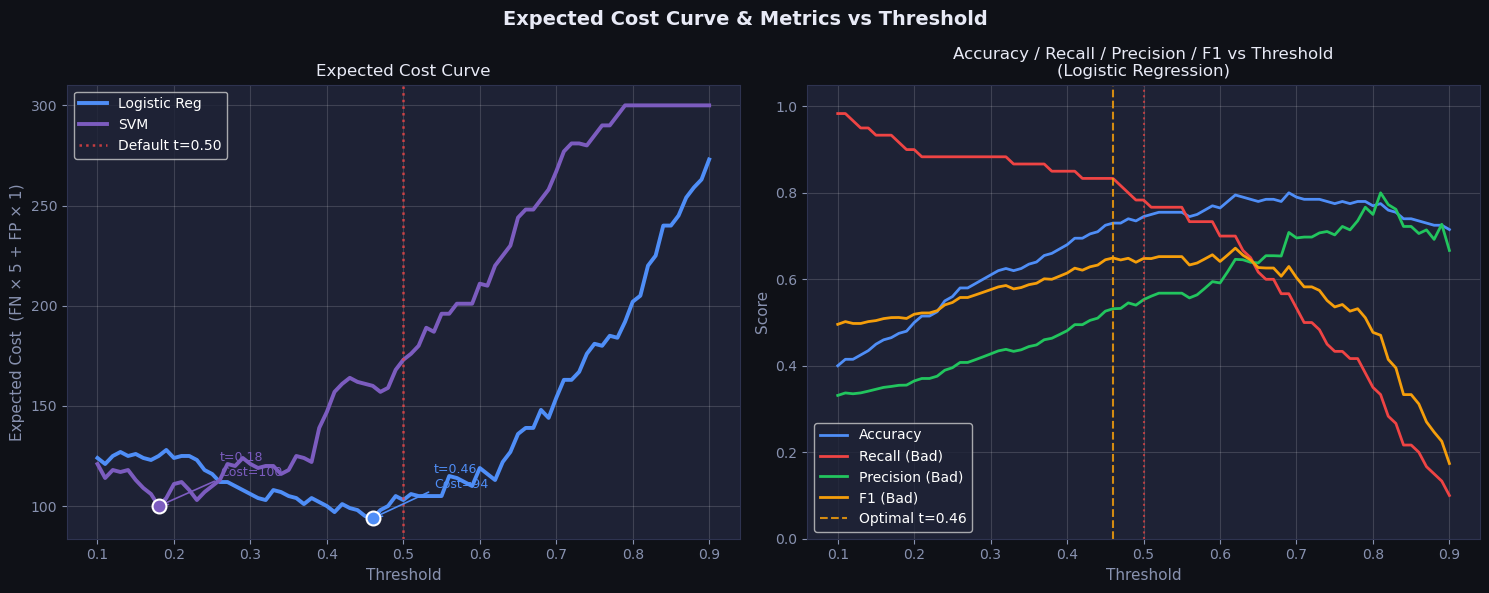

💾 Lưu: cost_curve.png

📌 Optimal threshold (LR)  : t = 0.46  →  Min Cost = 94
📌 Optimal threshold (SVM) : t = 0.18  →  Min Cost = 100
📌 Threshold default  0.50 : Cost = 103


In [9]:
thresholds_fine = np.linspace(0.10, 0.90, 81)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Expected Cost Curve & Metrics vs Threshold',
             color=C['text'], fontsize=14, fontweight='bold')

best_t_lr = best_t_svm = 0.5
best_cost_lr = best_cost_svm = 9999

# ── Cost curve ────────────────────────────────────────────
ax1.set_facecolor(C['card'])
for prob, name, color in [(prob_lr,'Logistic Reg',C['lr']),(prob_svm,'SVM',C['svm'])]:
    costs = []
    for t in thresholds_fine:
        pred_t = (prob >= t).astype(int)
        cm_t   = confusion_matrix(y_test, pred_t)
        tn_, fp_, fn_, tp_ = cm_t.ravel()
        costs.append(fn_ * COST_FN + fp_ * COST_FP)
    ax1.plot(thresholds_fine, costs, color=color, linewidth=2.8, label=name)
    opt_idx  = int(np.argmin(costs))
    opt_t    = thresholds_fine[opt_idx]
    opt_cost = costs[opt_idx]
    ax1.scatter([opt_t], [opt_cost], color=color, s=100,
                zorder=5, edgecolors='white', linewidths=1.5)
    ax1.annotate(f't={opt_t:.2f}\nCost={opt_cost}',
                 xy=(opt_t, opt_cost),
                 xytext=(opt_t + 0.08, opt_cost + 15),
                 color=color, fontsize=9,
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    if name == 'Logistic Reg':
        best_t_lr   = opt_t
        best_cost_lr= opt_cost
    else:
        best_t_svm   = opt_t
        best_cost_svm= opt_cost

ax1.axvline(x=0.5, color=C['bad'], linestyle=':', linewidth=1.8,
            alpha=0.8, label='Default t=0.50')
ax1.set_xlabel('Threshold', color=C['muted'], fontsize=11)
ax1.set_ylabel(f'Expected Cost  (FN × {COST_FN} + FP × {COST_FP})',
               color=C['muted'], fontsize=11)
ax1.set_title('Expected Cost Curve', color=C['text'], fontsize=12)
ax1.legend(fontsize=10, facecolor=C['card'], labelcolor='white')
ax1.grid(alpha=0.15)
ax1.tick_params(colors=C['muted'])
for spine in ax1.spines.values(): spine.set_edgecolor(C['border'])

# ── Metrics vs Threshold ──────────────────────────────────
ax2.set_facecolor(C['card'])
accs, recalls, f1s, precs, costs2 = [], [], [], [], []
for t in thresholds_fine:
    pred_t = (prob_lr >= t).astype(int)
    cm_t   = confusion_matrix(y_test, pred_t)
    tn_, fp_, fn_, tp_ = cm_t.ravel()
    acc_v  = (tn_ + tp_) / len(y_test)
    rec_v  = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    prec_v = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    f1_v   = 2 * prec_v * rec_v / (prec_v + rec_v) if (prec_v + rec_v) > 0 else 0
    accs.append(acc_v); recalls.append(rec_v)
    f1s.append(f1_v);  precs.append(prec_v)

ax2.plot(thresholds_fine, accs,    color=C['lr'],     linewidth=2, label='Accuracy')
ax2.plot(thresholds_fine, recalls, color=C['bad'],    linewidth=2, label='Recall (Bad)')
ax2.plot(thresholds_fine, precs,   color=C['good'],   linewidth=2, label='Precision (Bad)')
ax2.plot(thresholds_fine, f1s,     color=C['warn'],   linewidth=2, label='F1 (Bad)')

ax2.axvline(x=0.50,     color=C['bad'],  linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(x=best_t_lr,color=C['warn'], linestyle='--',linewidth=1.5, alpha=0.85,
            label=f'Optimal t={best_t_lr:.2f}')
ax2.set_xlabel('Threshold', color=C['muted'], fontsize=11)
ax2.set_ylabel('Score', color=C['muted'], fontsize=11)
ax2.set_title('Accuracy / Recall / Precision / F1 vs Threshold\n(Logistic Regression)',
              color=C['text'], fontsize=12)
ax2.legend(fontsize=10, facecolor=C['card'], labelcolor='white')
ax2.grid(alpha=0.15); ax2.set_ylim(0, 1.05)
ax2.tick_params(colors=C['muted'])
for spine in ax2.spines.values(): spine.set_edgecolor(C['border'])

plt.tight_layout()
plt.savefig('cost_curve.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print('💾 Lưu: cost_curve.png')
print()
print(f'📌 Optimal threshold (LR)  : t = {best_t_lr:.2f}  →  Min Cost = {best_cost_lr}')
print(f'📌 Optimal threshold (SVM) : t = {best_t_svm:.2f}  →  Min Cost = {best_cost_svm}')
print(f'📌 Threshold default  0.50 : Cost = {int(next(fn_*COST_FN+fp_*COST_FP for t in [0.5] for pred_t in [(prob_lr>=t).astype(int)] for cm_t in [confusion_matrix(y_test,pred_t)] for tn_,fp_,fn_,tp_ in [cm_t.ravel()]))}')

## 📊 Bước 10 — Dashboard Tổng Hợp (All-in-One)

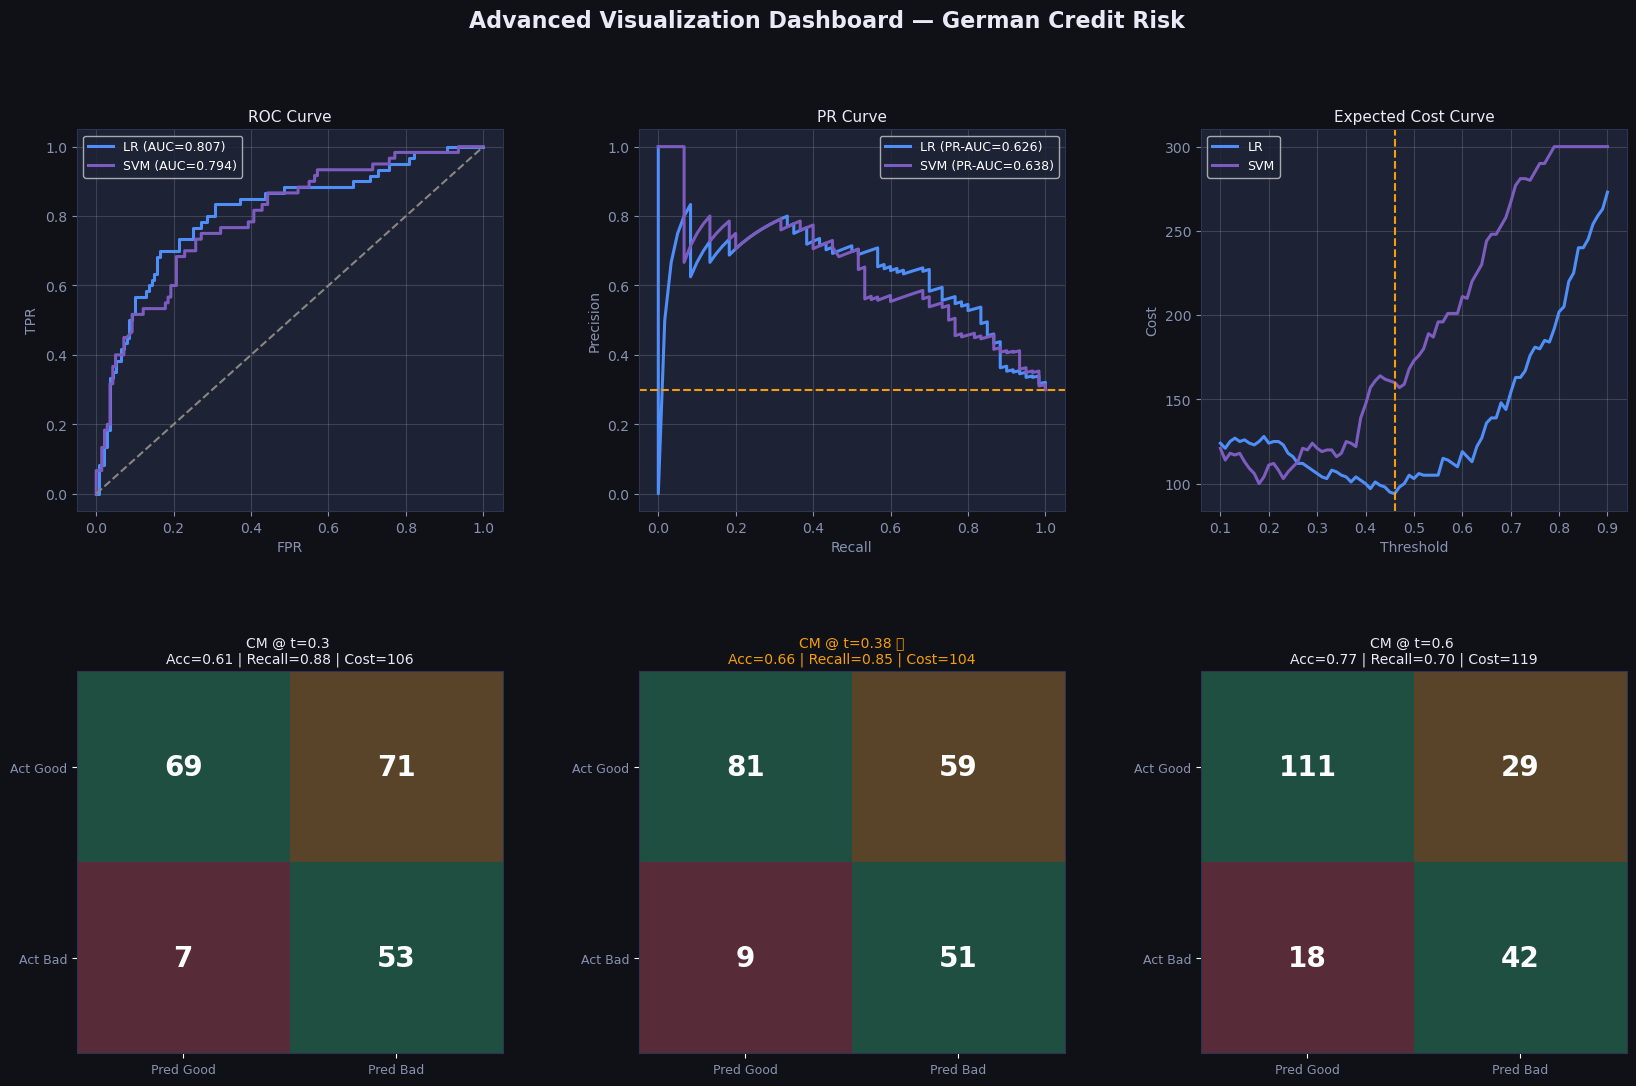

💾 Lưu: visualization_dashboard.png


In [10]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(C['bg'])
fig.suptitle('Advanced Visualization Dashboard — German Credit Risk',
             color=C['text'], fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
axes_all = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
for ax in axes_all:
    ax.set_facecolor(C['card'])
    for spine in ax.spines.values():
        spine.set_edgecolor(C['border'])

# [0] ROC
for prob, name, color in [(prob_lr,'LR',C['lr']),(prob_svm,'SVM',C['svm'])]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes_all[0].plot(fpr, tpr, color=color, linewidth=2.2,
                     label=f'{name} (AUC={roc_auc_score(y_test,prob):.3f})')
axes_all[0].plot([0,1],[0,1],'--',color=C['base'],linewidth=1.5)
axes_all[0].set_title('ROC Curve', color=C['text'], fontsize=11)
axes_all[0].set_xlabel('FPR',color=C['muted']); axes_all[0].set_ylabel('TPR',color=C['muted'])
axes_all[0].tick_params(colors=C['muted'])
axes_all[0].legend(fontsize=9,facecolor=C['card'],labelcolor='white')
axes_all[0].grid(alpha=0.15)

# [1] PR Curve
for prob, name, color in [(prob_lr,'LR',C['lr']),(prob_svm,'SVM',C['svm'])]:
    prec2, rec2, _ = precision_recall_curve(y_test, prob)
    axes_all[1].plot(rec2, prec2, color=color, linewidth=2.2,
                     label=f'{name} (PR-AUC={auc(rec2,prec2):.3f})')
axes_all[1].axhline(y=y_test.mean(),color=C['warn'],linestyle='--',linewidth=1.5)
axes_all[1].set_title('PR Curve', color=C['text'], fontsize=11)
axes_all[1].set_xlabel('Recall',color=C['muted']); axes_all[1].set_ylabel('Precision',color=C['muted'])
axes_all[1].tick_params(colors=C['muted'])
axes_all[1].legend(fontsize=9,facecolor=C['card'],labelcolor='white')
axes_all[1].grid(alpha=0.15)

# [2] Cost Curve
for prob, name, color in [(prob_lr,'LR',C['lr']),(prob_svm,'SVM',C['svm'])]:
    costs_v=[]
    for t in thresholds_fine:
        p=(prob>=t).astype(int)
        cm2=confusion_matrix(y_test,p); tn2,fp2,fn2,tp2=cm2.ravel()
        costs_v.append(fn2*COST_FN+fp2*COST_FP)
    axes_all[2].plot(thresholds_fine, costs_v, color=color, linewidth=2.2, label=name)
axes_all[2].axvline(x=best_t_lr,color=C['warn'],linestyle='--',linewidth=1.5)
axes_all[2].set_title('Expected Cost Curve', color=C['text'], fontsize=11)
axes_all[2].set_xlabel('Threshold',color=C['muted']); axes_all[2].set_ylabel('Cost',color=C['muted'])
axes_all[2].tick_params(colors=C['muted'])
axes_all[2].legend(fontsize=9,facecolor=C['card'],labelcolor='white')
axes_all[2].grid(alpha=0.15)

# [3][4][5] Confusion matrices tại 3 thresholds
for ax, t in zip(axes_all[3:], [0.30, 0.38, 0.60]):
    pred_cm = (prob_lr >= t).astype(int)
    cm_show = confusion_matrix(y_test, pred_cm)
    tn2, fp2, fn2, tp2 = cm_show.ravel()
    cell_colors2=[[C['good'],C['warn']],[C['bad'],C['good']]]
    cell_vals2=[[tn2,fp2],[fn2,tp2]]
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j,1-i),1,1,
                facecolor=cell_colors2[i][j],alpha=0.28,linewidth=0))
            ax.text(j+0.5,1.5-i,str(cell_vals2[i][j]),
                    ha='center',va='center',fontsize=20,fontweight='bold',color='white')
    ax.set_xlim(0,2); ax.set_ylim(0,2)
    ax.set_xticks([0.5,1.5]); ax.set_xticklabels(['Pred Good','Pred Bad'],color=C['muted'],fontsize=9)
    ax.set_yticks([0.5,1.5]); ax.set_yticklabels(['Act Bad','Act Good'],color=C['muted'],fontsize=9)
    cost_t=fn2*COST_FN+fp2*COST_FP
    rec_t=tp2/(tp2+fn2) if (tp2+fn2)>0 else 0
    acc_t=(tn2+tp2)/len(y_test)
    mark='⭐' if t==0.38 else ''
    ax.set_title(f'CM @ t={t} {mark}\nAcc={acc_t:.2f} | Recall={rec_t:.2f} | Cost={cost_t}',
                 color=C['warn'] if t==0.38 else C['text'],fontsize=10)

plt.savefig('visualization_dashboard.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show()
print('💾 Lưu: visualization_dashboard.png')

## 💡 Bước 11 — Tóm Tắt & Kết Luận

In [11]:
print('=' * 60)
print('  TÓM TẮT — ADVANCED VISUALIZATION')
print('=' * 60)
print(f'  Logistic Regression  ROC-AUC : {auc_lr:.4f}')
print(f'  SVM (RBF)            ROC-AUC : {auc_svm:.4f}')
print()
print(f'  Optimal Threshold (LR)  : {best_t_lr:.2f}  (Min Cost = {best_cost_lr})')
print(f'  Optimal Threshold (SVM) : {best_t_svm:.2f}  (Min Cost = {best_cost_svm})')
print()
print('  Tại threshold mặc định 0.50 (Logistic Reg):')
pred_05 = (prob_lr >= 0.50).astype(int)
cm_05   = confusion_matrix(y_test, pred_05)
tn5,fp5,fn5,tp5 = cm_05.ravel()
print(f'    Expected Cost = {fn5}×5 + {fp5}×1 = {fn5*5+fp5}')
print()
print(f'  Tại threshold tối ưu {best_t_lr:.2f} (Logistic Reg):')
pred_opt = (prob_lr >= best_t_lr).astype(int)
cm_opt   = confusion_matrix(y_test, pred_opt)
tn_o,fp_o,fn_o,tp_o = cm_opt.ravel()
print(f'    Expected Cost = {fn_o}×5 + {fp_o}×1 = {fn_o*5+fp_o}')
print(f'    ✅ Tiết kiệm: {fn5*5+fp5 - (fn_o*5+fp_o)} đơn vị cost')
print('=' * 60)
print()
print('📌 Kết luận quan trọng:')
print('   → Threshold 0.50 KHÔNG tối ưu cho bài toán có cost matrix 5:1')
print(f'   → Nên dùng threshold {best_t_lr:.2f} để giảm chi phí từ false negative')
print('   → Logistic Regression vượt SVM về cả AUC lẫn Expected Cost')

  TÓM TẮT — ADVANCED VISUALIZATION
  Logistic Regression  ROC-AUC : 0.8074
  SVM (RBF)            ROC-AUC : 0.7940

  Optimal Threshold (LR)  : 0.46  (Min Cost = 94)
  Optimal Threshold (SVM) : 0.18  (Min Cost = 100)

  Tại threshold mặc định 0.50 (Logistic Reg):
    Expected Cost = 13×5 + 38×1 = 103

  Tại threshold tối ưu 0.46 (Logistic Reg):
    Expected Cost = 10×5 + 44×1 = 94
    ✅ Tiết kiệm: 9 đơn vị cost

📌 Kết luận quan trọng:
   → Threshold 0.50 KHÔNG tối ưu cho bài toán có cost matrix 5:1
   → Nên dùng threshold 0.46 để giảm chi phí từ false negative
   → Logistic Regression vượt SVM về cả AUC lẫn Expected Cost
